In [2]:
!pip install pandas

In [3]:
import pandas as pd

df=pd.read_csv("/content/Walmart_Sales.csv")

In [4]:
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   object 
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 402.3+ KB


In [6]:
df.describe()

,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
count,6435.000000,6.435000e+03,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000
mean,23.000000,1.046965e+06,0.069930,60.663782,3.358607,171.578394,7.999151
std,12.988182,5.643666e+05,0.255049,18.444933,0.459020,39.356712,1.875885
min,1.000000,2.099862e+05,0.000000,-2.060000,2.472000,126.064000,3.879000
25%,12.000000,5.533501e+05,0.000000,47.460000,2.933000,131.735000,6.891000
50%,23.000000,9.607460e+05,0.000000,62.670000,3.445000,182.616521,7.874000
75%,34.000000,1.420159e+06,0.000000,74.940000,3.735000,212.743293,8.622000
max,45.000000,3.818686e+06,1.000000,100.140000,4.468000,227.232807,14.313000


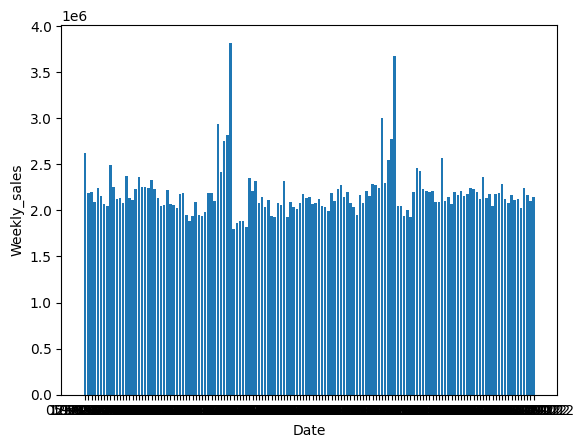

In [7]:
import matplotlib.pyplot as plt

plt.bar(df["Date"],df["Weekly_Sales"])
plt.xlabel("Date")
plt.ylabel("Weekly_sales")
plt.show()

In [8]:
df["Date"] = pd.to_datetime(df["Date"], dayfirst=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Store         6435 non-null   int64         
 1   Date          6435 non-null   datetime64[ns]
 2   Weekly_Sales  6435 non-null   float64       
 3   Holiday_Flag  6435 non-null   int64         
 4   Temperature   6435 non-null   float64       
 5   Fuel_Price    6435 non-null   float64       
 6   CPI           6435 non-null   float64       
 7   Unemployment  6435 non-null   float64       
dtypes: datetime64[ns](1), float64(5), int64(2)
memory usage: 402.3 KB


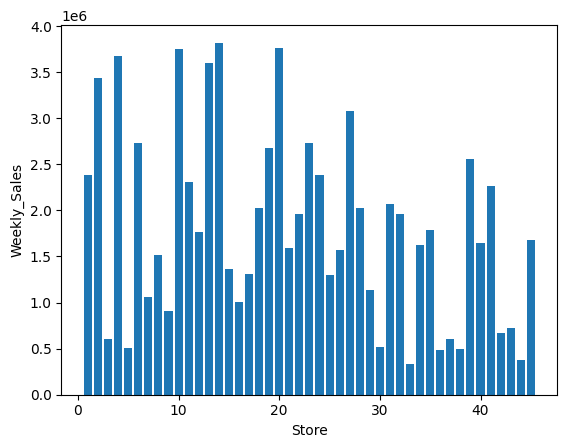

In [9]:
import matplotlib.pyplot as plt

plt.bar(df["Store"],df["Weekly_Sales"])
plt.xlabel("Store")
plt.ylabel("Weekly_Sales")
plt.show()

In [10]:
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,2010-02-05,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,2010-02-12,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,2010-02-19,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,2010-02-26,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,2010-03-05,1554806.68,0,46.50,2.625,211.350143,8.106


In [11]:
df["Month"] = df["Date"].dt.month

In [12]:
df["day_of_week"] = df["Date"].dt.day_of_week

In [13]:
df["is_weekend"] = df["Date"].dt.weekday>=5

In [14]:
Sales_per_store=df.groupby("Store")["Weekly_Sales"].sum()


In [15]:
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Month,day_of_week,is_weekend
0,1,2010-02-05,1643690.90,0,42.31,2.572,211.096358,8.106,2,4,False
1,1,2010-02-12,1641957.44,1,38.51,2.548,211.242170,8.106,2,4,False
2,1,2010-02-19,1611968.17,0,39.93,2.514,211.289143,8.106,2,4,False
3,1,2010-02-26,1409727.59,0,46.63,2.561,211.319643,8.106,2,4,False
4,1,2010-03-05,1554806.68,0,46.50,2.625,211.350143,8.106,3,4,False


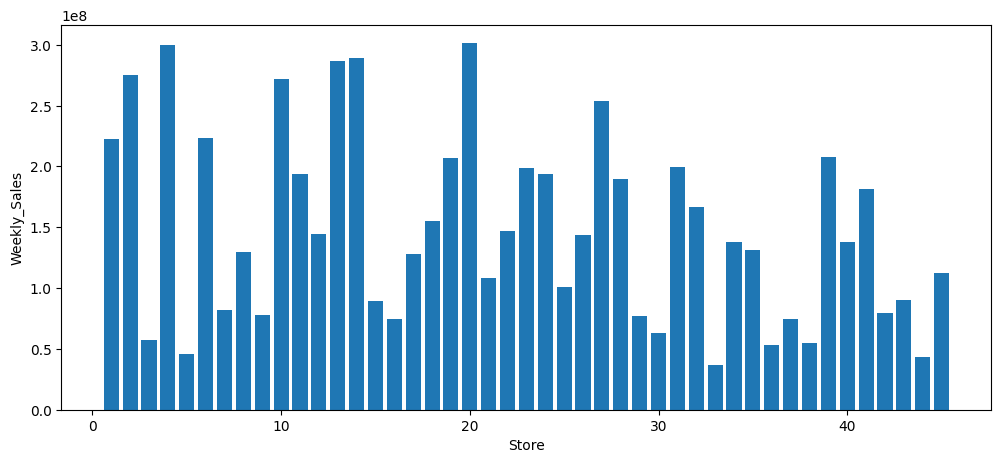

In [16]:
plt.figure(figsize=(12,5))
plt.bar(Sales_per_store.index,Sales_per_store.values)
plt.xlabel("Store")
plt.ylabel("Weekly_Sales")
plt.show()

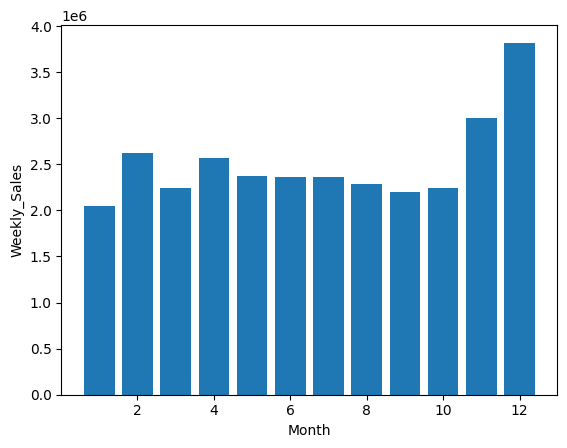

In [17]:
monthly_sales=df.groupby("Month")["Weekly_Sales"].sum()
plt.bar(df['Month'],df['Weekly_Sales'])
plt.xlabel("Month")
plt.ylabel("Weekly_Sales")
plt.show()

In [18]:
holiday_Sales=df.groupby("Holiday_Flag")["Weekly_Sales"].mean()
holiday_Sales

,Weekly_Sales
Holiday_Flag,
0,1.041256e+06
1,1.122888e+06


/tmp/ipython-input-925/538319250.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


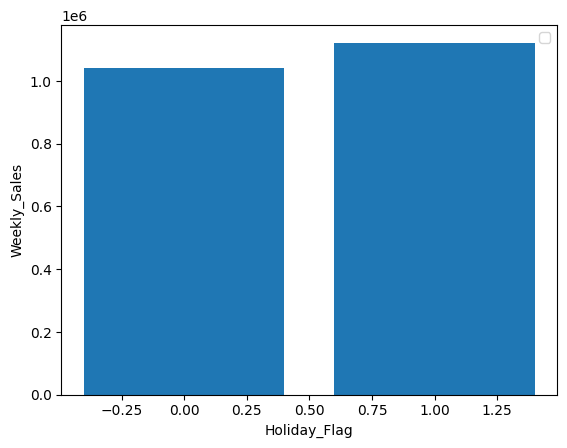

In [19]:
holiday_Sales=df.groupby("Holiday_Flag")["Weekly_Sales"].mean()
plt.bar(holiday_Sales.index,holiday_Sales.values)
plt.xlabel("Holiday_Flag")
plt.ylabel("Weekly_Sales")
plt.legend()
plt.show()

In [20]:
corr=df.corr(numeric_only=True)
corr

,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Month,day_of_week,is_weekend
Store,1.000000e+00,-0.335332,-4.386841e-16,-0.022659,0.060023,-0.209492,0.223531,2.910676e-15,NaN,NaN
Weekly_Sales,-3.353320e-01,1.000000,3.689097e-02,-0.063810,0.009464,-0.072634,-0.106176,7.614332e-02,NaN,NaN
Holiday_Flag,-4.386841e-16,0.036891,1.000000e+00,-0.155091,-0.078347,-0.002162,0.010960,1.229958e-01,NaN,NaN
Temperature,-2.265908e-02,-0.063810,-1.550913e-01,1.000000,0.144982,0.176888,0.101158,2.358618e-01,NaN,NaN
Fuel_Price,6.002295e-02,0.009464,-7.834652e-02,0.144982,1.000000,-0.170642,-0.034684,-4.215590e-02,NaN,NaN
CPI,-2.094919e-01,-0.072634,-2.162091e-03,0.176888,-0.170642,1.000000,-0.302020,4.979672e-03,NaN,NaN
Unemployment,2.235313e-01,-0.106176,1.096028e-02,0.101158,-0.034684,-0.302020,1.000000,-1.274559e-02,NaN,NaN
Month,2.910676e-15,0.076143,1.229958e-01,0.235862,-0.042156,0.004980,-0.012746,1.000000e+00,NaN,NaN
day_of_week,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
is_weekend,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


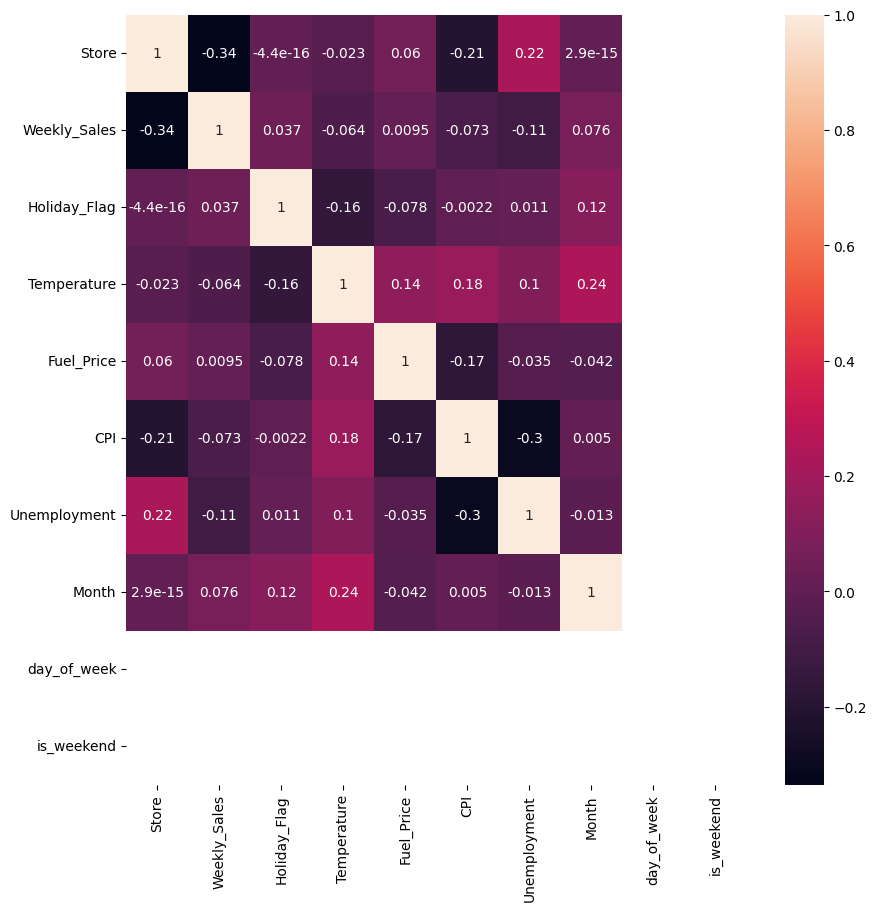

In [21]:
import seaborn as sns
plt.figure(figsize=(10,10))
sns.heatmap(corr,annot=True)
plt.show()

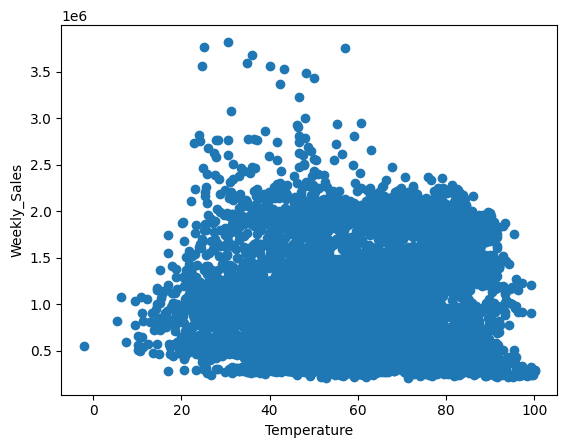

In [22]:
plt.scatter(df["Temperature"],df["Weekly_Sales"])
plt.xlabel("Temperature")
plt.ylabel("Weekly_Sales")
plt.show()

In [23]:
top_5_stores=df.groupby("Store")["Weekly_Sales"].sum().sort_values(ascending=False)
top_5_stores.head()

,Weekly_Sales
Store,
20,3.013978e+08
4,2.995440e+08
14,2.889999e+08
13,2.865177e+08
2,2.753824e+08


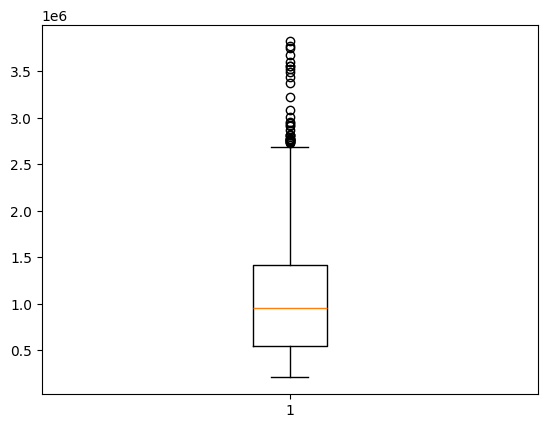

In [24]:
plt.boxplot(df["Weekly_Sales"])
plt.show()

In [25]:
df.sort_values("Weekly_Sales",ascending=False).head(10)

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Month,day_of_week,is_weekend
1905,14,2010-12-24,3818686.45,0,30.59,3.141,182.544590,8.724,12,4,False
2763,20,2010-12-24,3766687.43,0,25.17,3.141,204.637673,7.484,12,4,False
1333,10,2010-12-24,3749057.69,0,57.06,3.236,126.983581,9.003,12,4,False
527,4,2011-12-23,3676388.98,0,35.92,3.103,129.984548,5.143,12,4,False
1762,13,2010-12-24,3595903.20,0,34.90,2.846,126.983581,7.795,12,4,False
1814,13,2011-12-23,3556766.03,0,24.76,3.186,129.984548,6.392,12,4,False
2815,20,2011-12-23,3555371.03,0,40.19,3.389,212.236040,7.082,12,4,False
475,4,2010-12-24,3526713.39,0,43.21,2.887,126.983581,7.127,12,4,False
1385,10,2011-12-23,3487986.89,0,48.36,3.541,129.984548,7.874,12,4,False
189,2,2010-12-24,3436007.68,0,49.97,2.886,211.064660,8.163,12,4,False


In [26]:
Month_sales=df.groupby("Month")["Weekly_Sales"].mean()
Month_sales

,Weekly_Sales
Month,
1,9.238846e+05
2,1.053200e+06
3,1.013309e+06
4,1.026762e+06
5,1.031714e+06
6,1.064325e+06
7,1.031748e+06
8,1.048017e+06
9,9.893353e+05


December is clearly highest average month


In [29]:
df.head(8)

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Month,day_of_week,is_weekend
0,1,2010-02-05,1643690.90,0,42.31,2.572,211.096358,8.106,2,4,False
1,1,2010-02-12,1641957.44,1,38.51,2.548,211.242170,8.106,2,4,False
2,1,2010-02-19,1611968.17,0,39.93,2.514,211.289143,8.106,2,4,False
3,1,2010-02-26,1409727.59,0,46.63,2.561,211.319643,8.106,2,4,False
4,1,2010-03-05,1554806.68,0,46.50,2.625,211.350143,8.106,3,4,False
5,1,2010-03-12,1439541.59,0,57.79,2.667,211.380643,8.106,3,4,False
6,1,2010-03-19,1472515.79,0,54.58,2.720,211.215635,8.106,3,4,False
7,1,2010-03-26,1404429.92,0,51.45,2.732,211.018042,8.106,3,4,False


In [31]:
X=df[["Store","Holiday_Flag","Temperature","Fuel_Price","CPI","Unemployment","Month"]]
Y=df["Weekly_Sales"]

In [35]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,Y, test_size=0.2, random_state=42
)

In [36]:
from sklearn.linear_model import LinearRegression

model=LinearRegression()
model.fit(X_train,y_train)

LinearRegression()

In [38]:
from sklearn.metrics import r2_score,mean_absolute_error

y_pred=model.predict(X_test)
score=r2_score(y_test,y_pred)
print(score)
Mae=mean_absolute_error(y_test,y_pred)
print(Mae)

0.15492918523733978
432736.6308761738


In [39]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [40]:
y_pred_rf = rf.predict(X_test)

print("R2:", r2_score(y_test, y_pred_rf))
print("MAE:", mean_absolute_error(y_test, y_pred_rf))


R2: 0.9393237522981044
MAE: 72352.06866169386


In [41]:
import pandas as pd

importance = pd.Series(rf.feature_importances_, index=X.columns)
importance.sort_values(ascending=False)

,0
Store,0.664598
CPI,0.161788
Unemployment,0.104012
Month,0.030150
Temperature,0.019091
Fuel_Price,0.015647
Holiday_Flag,0.004714


In [42]:
import pickle

with open("walmart_sales_model.pkl", "wb") as f:
    pickle.dump(rf, f)